# Experiment 5: Ensemble Diversity Analysis for Jaguar Re-Identification

**Research Question:** Does a trained ensemble fusion model where a single ArcFace head learns from the concatenated embeddings of multiple diverse frozen backbones — outperform any individual model, and do the diversity and compute tradeoffs justify it?

## Key Design Decision: Fusion Happens During Training

Unlike post-hoc averaging (combining already-trained models at inference), this experiment trains a **fusion head that sees all backbone signals simultaneously**. The projection network learns which backbone's features are most discriminative for each identity.

```
Backbone 1 (MegaDescriptor) ──► emb₁ (1536-d) ─┐
Backbone 2 (DINOv2)         ──► emb₂ (1024-d) ─┤─► concat (5376-d) ──► FusionHead ──► 256-d ArcFace
Backbone 3 (EfficientNet)   ──► emb₃ (1792-d) ─┤
Backbone 4 (ConvNeXt)       ──► emb₄ (1024-d) ─┘
```

## Overview

1. **Data Loading**: Stratified train/validation split
2. **Backbone Embedding Extraction**: All 4 frozen backbones extract embeddings (cached)
3. **Individual Model Training**: Train 4 separate ArcFace heads (comparison baseline)
4. **Fusion Model Training**: Train 1 ArcFace head on concatenated embeddings
5. **mAP Comparison**: Individual models vs trained fusion ensemble
6. **Diversity Evidence**: Error-overlap, per-identity gains, representational similarity
7. **Compute Tradeoff**: Latency and parameter cost vs mAP gain
8. **Submission**: Best method used for final predictions

## Models in Ensemble (Chosen for Diversity)

| Model | Architecture | Pretrained On | Embed Dim | Diversity Rationale |
|---|---|---|---|---|
| **MegaDescriptor-L-384** | ViT-L (Swin) | Wildlife Re-ID | 1536 | Domain-specific wildlife identity features |
| **DINOv2-ViT-L/14** | ViT-L | LVD-142M (self-supervised) | 1024 | No label bias; rich semantic representations |
| **EfficientNet-B4** | CNN | ImageNet | 1792 | Local texture/edge features, CNN inductive bias |
| **ConvNeXt-V2-Base** | CNN-Transformer | ImageNet-22K | 1024 | Hybrid; bridges CNN locality and global attention |


## 1. Setup and Configuration

In [1]:
import os
import time
import math
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
import wandb
from kaggle_secrets import UserSecretsClient

# Secrets 
user_secrets = UserSecretsClient()
os.environ["HF_TOKEN"]      = user_secrets.get_secret("hf_api")
os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")

# Reproducibility
RANDOM_SEED = 42

def set_seed(seed: int) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(RANDOM_SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}  |  timm: {timm.__version__}")


Device: cuda
PyTorch: 2.9.0+cu126  |  timm: 1.0.24


In [2]:
# Backbone configs
ENSEMBLE_CONFIGS = [
    {
        "name":       "MegaDescriptor-L-384",
        "model_id":   "hf-hub:BVRA/MegaDescriptor-L-384",
        "input_size": 384,
        "arch_type":  "vit",
        "diversity":  "Domain-specific wildlife re-ID pretraining",
    },
    {
        "name":       "DINOv2-ViT-L-14",
        "model_id":   "vit_large_patch14_dinov2.lvd142m",
        "input_size": 518,
        "arch_type":  "vit",
        "diversity":  "Self-supervised (DINO v2), no label bias",
    },
    {
        "name":       "EfficientNet-B4",
        "model_id":   "efficientnet_b4",
        "input_size": 380,
        "arch_type":  "cnn",
        "diversity":  "CNN inductive bias, local texture and edge features",
    },
    {
        "name":       "ConvNeXt-V2-Base",
        "model_id":   "convnextv2_base.fcmae_ft_in22k_in1k_384",
        "input_size": 384,
        "arch_type":  "cnn",
        "diversity":  "Hybrid CNN-Transformer, bridges local and global features",
    },
]

RANDOM_SEED = 42

config = {
    # Paths
    "data_dir":       Path("/kaggle/input/competitions/jaguar-re-id"),
    "checkpoint_dir": Path("checkpoints"),
    "cache_dir":      Path("/kaggle/working/embeddings"),

    # Shared model settings (identical for individual AND fusion models)
    "embedding_dim":  256,
    "hidden_dim":     512,
    "dropout":        0.3,

    # ArcFace (same for all)
    "arcface_margin": 0.5,
    "arcface_scale":  64.0,

    # Training (same for all)
    "batch_size":     32,
    "learning_rate":  1e-4,
    "weight_decay":   1e-4,
    "num_epochs":     50,
    "patience":       10,
    "val_split":      0.2,
    "seed":           RANDOM_SEED,
}

config["checkpoint_dir"].mkdir(exist_ok=True)
config["cache_dir"].mkdir(parents=True, exist_ok=True)

print("Ensemble Configuration:")
print(f"  Backbones: {[m['name'] for m in ENSEMBLE_CONFIGS]}")
print(f"  Embedding dim (output): {config['embedding_dim']}")
print(f"  ArcFace margin={config['arcface_margin']}, scale={config['arcface_scale']}")
print(f"  Epochs: {config['num_epochs']}, patience: {config['patience']}")
print()
print("Fusion strategy: CONCATENATE all backbone embeddings → train single ArcFace head")


Ensemble Configuration:
  Backbones: ['MegaDescriptor-L-384', 'DINOv2-ViT-L-14', 'EfficientNet-B4', 'ConvNeXt-V2-Base']
  Embedding dim (output): 256
  ArcFace margin=0.5, scale=64.0
  Epochs: 50, patience: 10

Fusion strategy: CONCATENATE all backbone embeddings → train single ArcFace head


In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: pranav-birari (pranav-birari-university-of-potsdam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
wandb.init(
    project=os.getenv("WANDB_PROJECT", "jaguar-reid-iota"),
    config={
        "experiment":         "ensemble-diversity",
        "models_in_ensemble": [m["name"] for m in ENSEMBLE_CONFIGS],
        "num_backbones":      len(ENSEMBLE_CONFIGS),
        "fusion_strategy":    "concat_then_train",
        "embedding_dim":      config["embedding_dim"],
        "hidden_dim":         config["hidden_dim"],
        "dropout":            config["dropout"],
        "arcface_margin":     config["arcface_margin"],
        "arcface_scale":      config["arcface_scale"],
        "batch_size":         config["batch_size"],
        "learning_rate":      config["learning_rate"],
        "weight_decay":       config["weight_decay"],
        "num_epochs":         config["num_epochs"],
        "patience":           config["patience"],
        "val_split":          config["val_split"],
        "seed":               config["seed"],
    },
    name="ensemble-diversity",
)
print("W&B run: ensemble-diversity-(single run for entire experiment)")


W&B run: ensemble-diversity-(single run for entire experiment)


## 2. Load and Prepare Data

Total images: 1895  |  Identities: 31
Train: 1516  |  Val: 379  |  Classes: 31


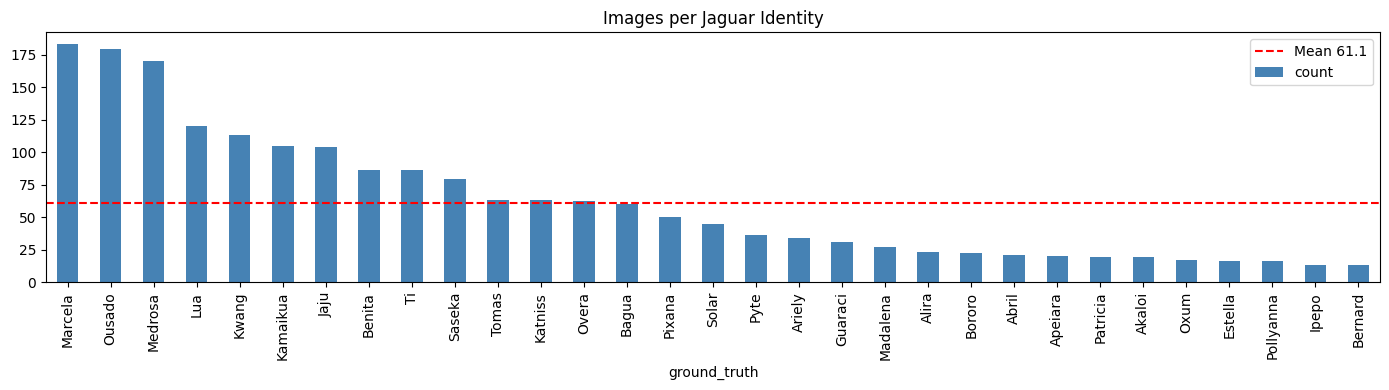

In [5]:
train_df = pd.read_csv(config["data_dir"] / "train.csv")
print(f"Total images: {len(train_df)}  |  Identities: {train_df['ground_truth'].nunique()}")

# Stratified split
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth'],
)
print(f"Train: {len(train_data)}  |  Val: {len(val_data)}  |  Classes: {num_classes}")

train_labels_enc = train_data['label_encoded'].values
val_labels_enc   = label_encoder.transform(val_data['ground_truth'].values)
val_labels_str   = val_data['ground_truth'].values

train_paths = [config["data_dir"] / "train/train" / fn
               for fn in train_data["filename"].astype(str)]
val_paths   = [config["data_dir"] / "train/train" / fn
               for fn in val_data["filename"].astype(str)]

# Visualise identity distribution
fig, ax = plt.subplots(figsize=(14, 4))
counts = train_df['ground_truth'].value_counts()
counts.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(counts.mean(), color='red', linestyle='--', label=f'Mean {counts.mean():.1f}')
ax.set_title('Images per Jaguar Identity')
ax.legend()
plt.tight_layout()
wandb.log({"identity_distribution": wandb.Image(fig)})
plt.show()


## 3. Backbone Loading and Embedding Extraction

All backbones are **fully frozen**. Embeddings are extracted once and cached to disk.
The fusion happens at the feature level — we concatenate the raw backbone embeddings
before any learned projection, so the ArcFace head can learn cross-backbone interactions.


In [6]:
def load_backbone(cfg, device):
    """Load a frozen timm backbone. CNNs don't accept img_size kwarg."""
    print(f"Loading {cfg['name']}...")
    is_cnn = any(s in cfg['model_id'].lower()
                 for s in ['efficientnet', 'convnext', 'resnet'])
    kwargs = dict(pretrained=True, num_classes=0)
    if not is_cnn:
        kwargs['img_size'] = cfg['input_size']
    model = timm.create_model(cfg['model_id'], **kwargs)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    model.to(device)
    with torch.no_grad():
        dummy   = torch.randn(1, 3, cfg['input_size'], cfg['input_size']).to(device)
        emb_dim = model(dummy).shape[1]
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  embed_dim={emb_dim}  params={n_params:,}  frozen=True")
    return model, emb_dim, n_params


def get_transforms(input_size):
    return transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])


@torch.no_grad()
def extract_embeddings(model, image_paths, transform, batch_size=32, desc=""):
    """Extract (N, D) embeddings; caches-friendly, returns numpy array."""
    model.eval()
    all_embs = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        paths   = image_paths[i:i + batch_size]
        tensors = []
        for p in paths:
            try:
                tensors.append(transform(Image.open(p).convert("RGB")))
            except Exception as e:
                print(f"  [WARN] {p}: {e}")
                tensors.append(torch.zeros(3, transform.transforms[0].size[0],
                                           transform.transforms[0].size[0]))
        all_embs.append(model(torch.stack(tensors).to(device)).cpu().numpy())
    return np.vstack(all_embs)

print("Backbone utilities defined.")


Backbone utilities defined.


## 4. Extract Embeddings from All Backbones

We extract and cache embeddings for every backbone once.
These cached arrays are reused for:
- Training each **individual** ArcFace head
- Building the **concatenated** feature matrix for the fusion head


In [7]:
# Stores: name -> {"train": ndarray, "val": ndarray, "dim": int, "params": int}
backbone_embs   = {}
backbone_params = {}

for cfg in ENSEMBLE_CONFIGS:
    name      = cfg["name"]
    safe      = name.replace("/", "-").replace(" ", "_")
    transform = get_transforms(cfg["input_size"])
    tr_cache  = config["cache_dir"] / f"{safe}_train.npz"
    va_cache  = config["cache_dir"] / f"{safe}_val.npz"

    # Load backbone for extraction (unloaded after to save memory)
    backbone, emb_dim, n_params = load_backbone(cfg, device)
    backbone_params[name] = n_params

    if tr_cache.exists():
        tr_emb = np.load(tr_cache)["embeddings"]
        print(f"  {name}: loaded train cache {tr_emb.shape}")
    else:
        print(f"  {name}: extracting train embeddings...")
        tr_emb = extract_embeddings(backbone, train_paths, transform,
                                    config["batch_size"], desc=f"{name} train")
        np.savez_compressed(tr_cache, embeddings=tr_emb)

    if va_cache.exists():
        va_emb = np.load(va_cache)["embeddings"]
        print(f"  {name}: loaded val cache {va_emb.shape}")
    else:
        print(f"  {name}: extracting val embeddings...")
        va_emb = extract_embeddings(backbone, val_paths, transform,
                                    config["batch_size"], desc=f"{name} val")
        np.savez_compressed(va_cache, embeddings=va_emb)

    backbone_embs[name] = {"train": tr_emb, "val": va_emb, "dim": emb_dim}
    del backbone
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

# Build concatenated features
fused_train = np.concatenate([backbone_embs[m["name"]]["train"]
                               for m in ENSEMBLE_CONFIGS], axis=1)
fused_val   = np.concatenate([backbone_embs[m["name"]]["val"]
                               for m in ENSEMBLE_CONFIGS], axis=1)
fused_dim   = fused_train.shape[1]

print(f"\nConcatenated embedding dim: {fused_dim}")
print(f"  = {' + '.join(str(backbone_embs[m['name']]['dim']) for m in ENSEMBLE_CONFIGS)}")
print(f"  Train shape: {fused_train.shape}")
print(f"  Val shape:   {fused_val.shape}")


Loading MegaDescriptor-L-384...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

  embed_dim=1536  params=195,198,516  frozen=True
  MegaDescriptor-L-384: extracting train embeddings...


MegaDescriptor-L-384 train:   0%|          | 0/48 [00:00<?, ?it/s]

...

  embed_dim=1024  params=87,692,800  frozen=True
  ConvNeXt-V2-Base: extracting train embeddings...


ConvNeXt-V2-Base train:   0%|          | 0/48 [00:00<?, ?it/s]

  ConvNeXt-V2-Base: extracting val embeddings...


ConvNeXt-V2-Base val:   0%|          | 0/12 [00:00<?, ?it/s]


Concatenated embedding dim: 5376
  = 1536 + 1024 + 1792 + 1024
  Train shape: (1516, 5376)
  Val shape:   (379, 5376)


## 5. Model Architecture

One shared `ArcFaceModel` class is used for **both** individual and fusion models.
The only difference is `input_dim`:
- Individual model: `input_dim = backbone_dim` (e.g. 1536 for MegaDescriptor)
- Fusion model: `input_dim = sum(all backbone dims)` = 5376


In [8]:
class EmbeddingProjection(nn.Module):
    """Linear → BN → ReLU → Dropout → Linear → BN. Works for any input_dim."""
    def __init__(self, input_dim, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)

    def forward(self, x): return self.net(x)


class ArcFaceHead(nn.Module):
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.scale = scale
        self.cos_m = math.cos(margin); self.sin_m = math.sin(margin)
        self.th    = math.cos(math.pi - margin)
        self.mm    = math.sin(math.pi - margin) * margin
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, emb, labels):
        emb_n = F.normalize(emb, p=2, dim=1)
        w_n   = F.normalize(self.weight, p=2, dim=1)
        cos   = torch.clamp(F.linear(emb_n, w_n), -1.0, 1.0)
        sin   = torch.sqrt(1.0 - cos ** 2)
        phi   = cos * self.cos_m - sin * self.sin_m
        phi   = torch.where(cos > self.th, phi, cos - self.mm)
        oh    = torch.zeros_like(cos).scatter_(1, labels.view(-1, 1).long(), 1.0)
        return (oh * phi + (1 - oh) * cos) * self.scale


class ArcFaceModel(nn.Module):
    """Projection head + ArcFace. Works for both individual and fusion models."""
    def __init__(self, input_dim, num_classes, embedding_dim=256,
                 hidden_dim=512, margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()
        self.projection = EmbeddingProjection(input_dim, hidden_dim,
                                               embedding_dim, dropout)
        self.arcface    = ArcFaceHead(embedding_dim, num_classes,
                                      margin=margin, scale=scale)

    def forward(self, x, labels):
        emb    = self.projection(x)
        logits = self.arcface(emb, labels)
        return logits, emb

    def get_embeddings(self, x):
        return F.normalize(self.projection(x), p=2, dim=1)


# Sanity checks
for label, dim in [("Individual (MegaDescriptor)", 1536),
                    ("Fusion (all 4 backbones)", fused_dim)]:
    m = ArcFaceModel(input_dim=dim, num_classes=num_classes).to(device)
    x = torch.randn(4, dim).to(device)
    l = torch.zeros(4, dtype=torch.long).to(device)
    logits, emb = m(x, l)
    n = sum(p.numel() for p in m.parameters())
    print(f"  {label}: logits={logits.shape}, emb={emb.shape}, params={n:,}")
    del m, x, l, logits, emb


  Individual (MegaDescriptor): logits=torch.Size([4, 31]), emb=torch.Size([4, 256]), params=927,744
  Fusion (all 4 backbones): logits=torch.Size([4, 31]), emb=torch.Size([4, 256]), params=2,893,824


## 6. Training Utilities

In [9]:
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels     = torch.LongTensor(labels)
    def __len__(self):           return len(self.labels)
    def __getitem__(self, idx):  return self.embeddings[idx], self.labels[idx]


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for emb, labels in tqdm(loader, desc='Train', leave=False):
        emb, labels = emb.to(device), labels.to(device)
        logits, _   = model(emb, labels)
        loss        = criterion(logits, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), 100. * correct / total


def validate_epoch(model, loader, criterion, device):
    model.eval(); total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for emb, labels in tqdm(loader, desc='Val', leave=False):
            emb, labels = emb.to(device), labels.to(device)
            logits, _   = model(emb, labels)
            loss        = criterion(logits, labels)
            total_loss += loss.item()
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), 100. * correct / total


def compute_map(model, val_embeddings, val_labels_str):
    """Identity-balanced mAP using the model's fine-tuned embeddings."""
    model.eval()
    with torch.no_grad():
        emb = model.get_embeddings(
            torch.FloatTensor(val_embeddings).to(device)).cpu().numpy()
    return _map_from_embeddings(emb, val_labels_str)


def _map_from_embeddings(emb, labels):
    """Identity-balanced mAP from a numpy embedding matrix."""
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    sim = emb @ emb.T; np.fill_diagonal(sim, -1)
    id_aps = defaultdict(list)
    for q in range(len(labels)):
        ql       = labels[q]
        is_match = (labels == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        order = np.argsort(-sim[q]); sm = is_match[order]
        cum   = np.cumsum(sm)
        prec  = cum / np.arange(1, len(sm)+1)
        id_aps[ql].append(float(np.sum(prec * sm) / n_pos))
    return float(np.mean([np.mean(v) for v in id_aps.values()]))


def run_training(model_name, input_dim, train_emb, val_emb,
                 train_labels, val_labels_str, config, device, wandb_prefix):
    """
    Train an ArcFaceModel on pre-extracted embeddings.
    Returns (best_map, best_epoch, history, finetuned_val_emb, checkpoint_path).
    """
    set_seed(config["seed"])
    model = ArcFaceModel(
        input_dim=input_dim, num_classes=num_classes,
        embedding_dim=config["embedding_dim"], hidden_dim=config["hidden_dim"],
        margin=config["arcface_margin"], scale=config["arcface_scale"],
        dropout=config["dropout"],
    ).to(device)

    tr_loader = DataLoader(EmbeddingDataset(train_emb, train_labels),
                            batch_size=config["batch_size"],
                            shuffle=True, num_workers=0)
    va_loader = DataLoader(EmbeddingDataset(val_emb,
                            label_encoder.transform(val_labels_str)),
                            batch_size=config["batch_size"],
                            shuffle=False, num_workers=0)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=config["learning_rate"],
                                  weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)

    history = {k: [] for k in
               ['train_loss','train_acc','val_loss','val_acc','val_map','lr']}
    best_val_loss, best_map, best_epoch = float('inf'), 0.0, 0
    patience_counter = 0
    safe  = model_name.replace("/", "-").replace(" ", "_")
    ckpt  = config["checkpoint_dir"] / f"{safe}_best.pth"

    for epoch in range(config["num_epochs"]):
        tr_loss, tr_acc = train_epoch(model, tr_loader, criterion, optimizer, device)
        va_loss, va_acc = validate_epoch(model, va_loader, criterion, device)
        va_map          = compute_map(model, val_emb, val_labels_str)
        scheduler.step(va_loss)
        lr = optimizer.param_groups[0]['lr']

        for k, v in zip(['train_loss','train_acc','val_loss','val_acc','val_map','lr'],
                        [tr_loss, tr_acc, va_loss, va_acc, va_map, lr]):
            history[k].append(v)

        wandb.log({f"{wandb_prefix}/epoch":      epoch + 1,
                   f"{wandb_prefix}/train_loss": tr_loss,
                   f"{wandb_prefix}/train_acc":  tr_acc,
                   f"{wandb_prefix}/val_loss":   va_loss,
                   f"{wandb_prefix}/val_acc":    va_acc,
                   f"{wandb_prefix}/val_map":    va_map,
                   f"{wandb_prefix}/lr":         lr})

        print(f"  [{model_name}] Epoch {epoch+1:3d} | "
              f"TrLoss={tr_loss:.4f} VaLoss={va_loss:.4f} "
              f"VamAP={va_map:.4f} LR={lr:.2e}")

        if va_loss < best_val_loss:
            best_val_loss = va_loss; best_map = va_map; best_epoch = epoch + 1
            patience_counter = 0
            torch.save({'epoch': best_epoch,
                        'model_state_dict': model.state_dict(),
                        'val_loss': float(best_val_loss),
                        'val_map':  float(best_map),
                        'model_name': model_name,
                        'input_dim': input_dim}, ckpt)
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    # Extract fine-tuned val embeddings for diversity analysis
    model.eval()
    with torch.no_grad():
        ft_emb = model.get_embeddings(
            torch.FloatTensor(val_emb).to(device)).cpu().numpy()

    wandb.log({f"{wandb_prefix}/best_val_map": best_map,
               f"{wandb_prefix}/best_epoch":   best_epoch})
    return best_map, best_epoch, history, ft_emb, str(ckpt)


print("run_training helper defined — used for both individual and fusion models.")


run_training helper defined — used for both individual and fusion models.


## 7. Train Individual Models (Comparison Baseline)

Each backbone's embeddings are fed to its own isolated ArcFace head.
These are the **individual baselines** we need to beat with the fusion model.
All hyperparameters are identical — the only variable is which backbone's features are used.


In [10]:
individual_results  = {}   # name -> {best_map, best_epoch, history, ft_emb, ckpt}
individual_head_params = {}

for cfg in ENSEMBLE_CONFIGS:
    name = cfg["name"]
    print("\n" + "="*65)
    print(f"INDIVIDUAL MODEL: {name}")
    print("="*65)

    tr_emb = backbone_embs[name]["train"]
    va_emb = backbone_embs[name]["val"]
    dim    = backbone_embs[name]["dim"]

    best_map, best_epoch, history, ft_emb, ckpt = run_training(
        model_name   = name,
        input_dim    = dim,
        train_emb    = tr_emb,
        val_emb      = va_emb,
        train_labels = train_labels_enc,
        val_labels_str = val_labels_str,
        config       = config,
        device       = device,
        wandb_prefix = f"individual/{name}",
    )
    individual_results[name] = {
        "best_map":   best_map,
        "best_epoch": best_epoch,
        "history":    history,
        "ft_emb":     ft_emb,
        "ckpt":       ckpt,
    }
    # Count projection head params
    m = ArcFaceModel(input_dim=dim, num_classes=num_classes).to(device)
    individual_head_params[name] = sum(p.numel() for p in m.parameters())
    del m

    print(f"  ✓ {name}: best_map={best_map:.4f} @ epoch {best_epoch}")

print("\n" + "="*65)
print("INDIVIDUAL MODEL RESULTS")
print("="*65)
for name, r in individual_results.items():
    print(f"  {name:30s} | mAP: {r['best_map']:.4f} | Epoch: {r['best_epoch']}")
best_individual_name = max(individual_results, key=lambda n: individual_results[n]['best_map'])
best_individual_map  = individual_results[best_individual_name]['best_map']
print(f"\nBest individual: {best_individual_name} (mAP={best_individual_map:.4f})")



INDIVIDUAL MODEL: MegaDescriptor-L-384


Train:   0%|          | 0/48 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  [MegaDescriptor-L-384] Epoch   1 | TrLoss=36.5123 VaLoss=31.5810 VamAP=0.3339 LR=1.00e-04


Train:   0%|          | 0/48 [00:00<?, ?it/s]

...

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  [ConvNeXt-V2-Base] Epoch  49 | TrLoss=1.2758 VaLoss=3.6335 VamAP=0.8247 LR=1.00e-04


Train:   0%|          | 0/48 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  [ConvNeXt-V2-Base] Epoch  50 | TrLoss=1.3287 VaLoss=3.5378 VamAP=0.8276 LR=1.00e-04
  ✓ ConvNeXt-V2-Base: best_map=0.8276 @ epoch 50

INDIVIDUAL MODEL RESULTS
  MegaDescriptor-L-384           | mAP: 0.7748 | Epoch: 50
  DINOv2-ViT-L-14                | mAP: 0.8257 | Epoch: 48
  EfficientNet-B4                | mAP: 0.8245 | Epoch: 50
  ConvNeXt-V2-Base               | mAP: 0.8276 | Epoch: 50

Best individual: ConvNeXt-V2-Base (mAP=0.8276)


## 8. Train Fusion Model (Ensemble — Learned During Training)

The fusion model sees **all backbone embeddings concatenated** into a single
`{fused_dim}`-dimensional vector. The ArcFace projection head must learn
which parts of the fused representation are most useful for each jaguar identity.

This is fundamentally different from post-hoc averaging: the head can learn
cross-backbone interactions and down-weight redundant or noisy features.


In [11]:
print("=" * 65)
print(f"FUSION MODEL: concat of {len(ENSEMBLE_CONFIGS)} backbones")
print(f"  Input dim: {fused_dim}  "
      f"({' + '.join(str(backbone_embs[m['name']]['dim']) for m in ENSEMBLE_CONFIGS)})")
print("=" * 65)

fusion_map, fusion_epoch, fusion_history, fusion_ft_emb, fusion_ckpt = run_training(
    model_name     = "FusionEnsemble",
    input_dim      = fused_dim,
    train_emb      = fused_train,
    val_emb        = fused_val,
    train_labels   = train_labels_enc,
    val_labels_str = val_labels_str,
    config         = config,
    device         = device,
    wandb_prefix   = "fusion",
)

fusion_head_params = sum(
    p.numel() for p in
    ArcFaceModel(input_dim=fused_dim, num_classes=num_classes).parameters()
)

print(f"\n✓ Fusion model: best_map={fusion_map:.4f} @ epoch {fusion_epoch}")
print(f"  Head params: {fusion_head_params:,}")
print(f"  Gain over best individual ({best_individual_name}): "
      f"{fusion_map - best_individual_map:+.4f}")

wandb.log({
    "fusion/best_val_map":           fusion_map,
    "fusion/gain_over_best_individual": fusion_map - best_individual_map,
    "fusion/input_dim":              fused_dim,
    "fusion/head_params":            fusion_head_params,
})


FUSION MODEL: concat of 4 backbones
  Input dim: 5376  (1536 + 1024 + 1792 + 1024)


Train:   0%|          | 0/48 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  [FusionEnsemble] Epoch   1 | TrLoss=35.4613 VaLoss=29.1926 VamAP=0.4057 LR=1.00e-04


Train:   0%|          | 0/48 [00:00<?, ?it/s]

...

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  [FusionEnsemble] Epoch  49 | TrLoss=0.1263 VaLoss=3.1436 VamAP=0.8300 LR=5.00e-05


Train:   0%|          | 0/48 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  [FusionEnsemble] Epoch  50 | TrLoss=0.1056 VaLoss=3.1402 VamAP=0.8327 LR=5.00e-05

✓ Fusion model: best_map=0.8358 @ epoch 48
  Head params: 2,893,824
  Gain over best individual (ConvNeXt-V2-Base): +0.0082


## 9. Diversity Evidence

To justify the ensemble, we must show the models make **complementary errors**.
We measure three things:

1. **Error-overlap matrix** — fraction of val queries where both models get top-1 wrong
2. **Per-identity AP gain** — which jaguar identities benefit from fusion
3. **Representational similarity** — cosine similarity between embedding spaces (lower = more diverse)


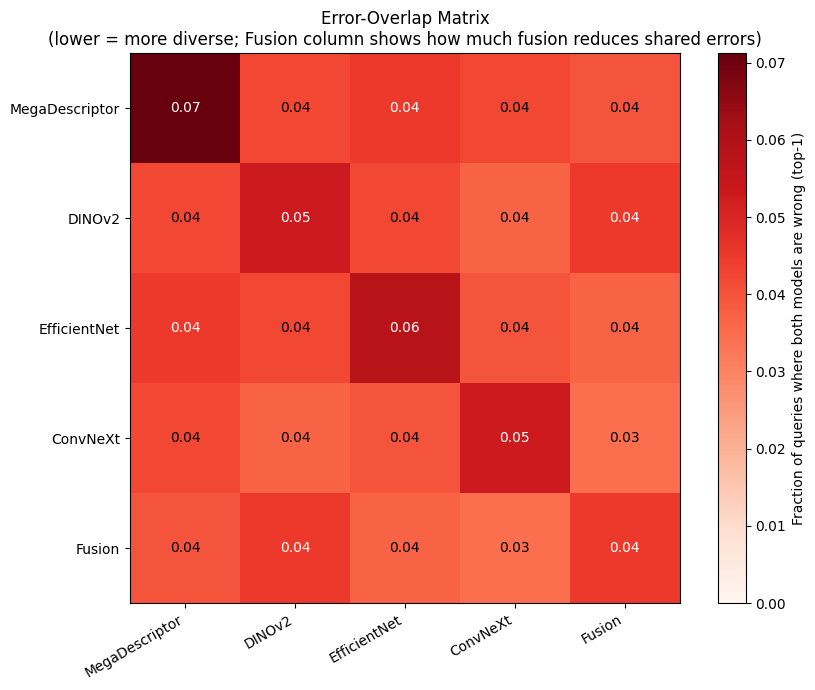

Mean pairwise error overlap (individual models): 0.0413
  0 = fully complementary, 1 = identical errors


In [12]:
model_names = list(individual_results.keys())
n_models    = len(model_names)
short_names = [n.split('-')[0] for n in model_names]

# Normalised fine-tuned val embeddings
norm_embs = {}
for name in model_names:
    e = individual_results[name]["ft_emb"]
    norm_embs[name] = e / (np.linalg.norm(e, axis=1, keepdims=True) + 1e-12)
fusion_norm = fusion_ft_emb / (
    np.linalg.norm(fusion_ft_emb, axis=1, keepdims=True) + 1e-12)

# 1. Error-overlap matrix
def top1_correct_mask(emb_norm, labels):
    sim   = emb_norm @ emb_norm.T; np.fill_diagonal(sim, -1)
    top1  = np.argmax(sim, axis=1)
    return (labels[top1] == labels).astype(int)

top1_masks = {n: top1_correct_mask(norm_embs[n], val_labels_str)
              for n in model_names}
top1_masks["FusionEnsemble"] = top1_correct_mask(fusion_norm, val_labels_str)

all_names_for_overlap = model_names + ["FusionEnsemble"]
n_all = len(all_names_for_overlap)

overlap = np.zeros((n_all, n_all))
for i, ni in enumerate(all_names_for_overlap):
    for j, nj in enumerate(all_names_for_overlap):
        both_wrong = ((top1_masks[ni] == 0) & (top1_masks[nj] == 0)).mean()
        overlap[i, j] = float(both_wrong)

all_short = [n.split('-')[0] for n in all_names_for_overlap[:-1]] + ["Fusion"]

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(overlap, cmap='Reds', vmin=0, vmax=overlap.max())
ax.set_xticks(range(n_all)); ax.set_xticklabels(all_short, rotation=30, ha='right')
ax.set_yticks(range(n_all)); ax.set_yticklabels(all_short)
for i in range(n_all):
    for j in range(n_all):
        ax.text(j, i, f"{overlap[i,j]:.2f}", ha='center', va='center',
                fontsize=10, color='white' if overlap[i,j] > overlap.max()*0.6 else 'black')
plt.colorbar(im, ax=ax, label='Fraction of queries where both models are wrong (top-1)')
ax.set_title('Error-Overlap Matrix\n(lower = more diverse; Fusion column shows '
             'how much fusion reduces shared errors)')
plt.tight_layout()
wandb.log({"diversity/error_overlap_heatmap": wandb.Image(fig)})
plt.show()

off_diag = overlap[:n_models, :n_models][~np.eye(n_models, dtype=bool)]
print(f"Mean pairwise error overlap (individual models): {off_diag.mean():.4f}")
print(f"  0 = fully complementary, 1 = identical errors")
wandb.log({"diversity/mean_error_overlap": float(off_diag.mean())})


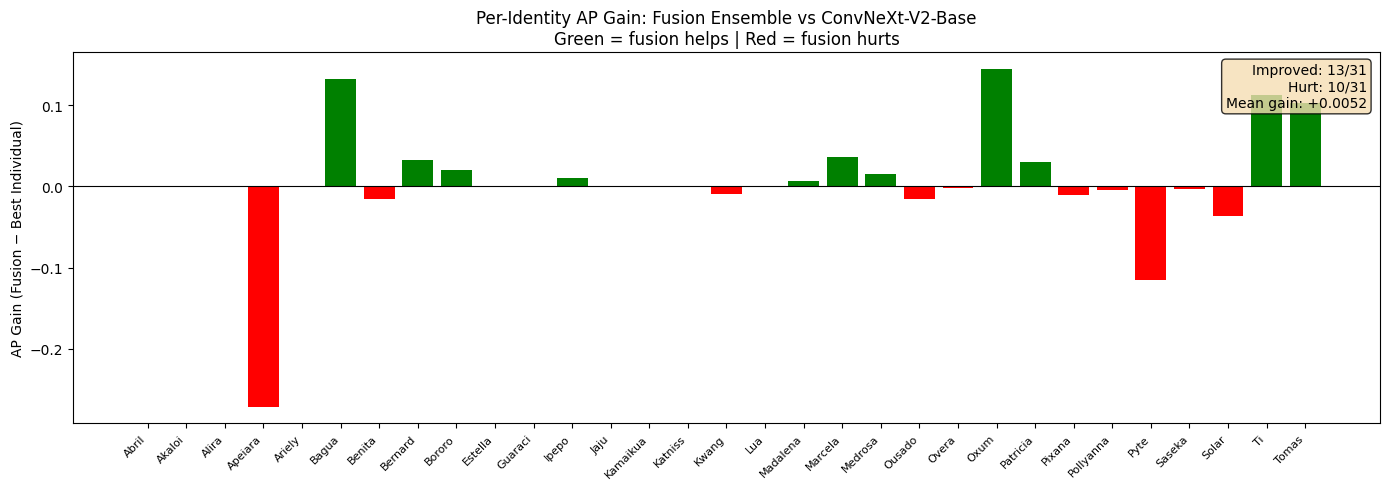

Per-identity summary (Fusion vs ConvNeXt-V2-Base):
  Improved: 13/31
  Hurt:     10/31
  Mean gain: +0.0052


In [13]:
# 2. Per-identity AP gain: fusion vs best individual
def per_identity_map(emb_norm, labels):
    sim = emb_norm @ emb_norm.T; np.fill_diagonal(sim, -1)
    id_aps = defaultdict(list)
    for q in range(len(labels)):
        ql       = labels[q]
        is_match = (labels == ql).astype(int); is_match[q] = 0
        n_pos    = is_match.sum()
        if n_pos == 0: continue
        order = np.argsort(-sim[q]); sm = is_match[order]
        cum   = np.cumsum(sm); prec = cum / np.arange(1, len(sm)+1)
        id_aps[ql].append(float(np.sum(prec * sm) / n_pos))
    return {k: float(np.mean(v)) for k, v in id_aps.items()}

best_ind_per_id = per_identity_map(norm_embs[best_individual_name], val_labels_str)
fusion_per_id   = per_identity_map(fusion_norm, val_labels_str)

identities = sorted(fusion_per_id.keys())
gains      = [fusion_per_id[i] - best_ind_per_id.get(i, 0.0) for i in identities]

n_improved = sum(1 for g in gains if g > 0)
n_hurt     = sum(1 for g in gains if g < 0)

fig, ax = plt.subplots(figsize=(14, 5))
colors  = ['green' if g > 0 else 'red' for g in gains]
ax.bar(range(len(identities)), gains, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(identities)))
ax.set_xticklabels(identities, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('AP Gain (Fusion − Best Individual)')
ax.set_title(f'Per-Identity AP Gain: Fusion Ensemble vs {best_individual_name}\n'
             f'Green = fusion helps | Red = fusion hurts')
ax.text(0.99, 0.97,
        f'Improved: {n_improved}/{len(identities)}\nHurt: {n_hurt}/{len(identities)}\n'
        f'Mean gain: {np.mean(gains):+.4f}',
        transform=ax.transAxes, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
plt.tight_layout()
wandb.log({"diversity/per_identity_gain": wandb.Image(fig)})
plt.show()

print(f"Per-identity summary (Fusion vs {best_individual_name}):")
print(f"  Improved: {n_improved}/{len(identities)}")
print(f"  Hurt:     {n_hurt}/{len(identities)}")
print(f"  Mean gain: {np.mean(gains):+.4f}")
wandb.log({
    "diversity/identities_improved": n_improved,
    "diversity/identities_hurt":     n_hurt,
    "diversity/mean_per_id_gain":    float(np.mean(gains)),
})


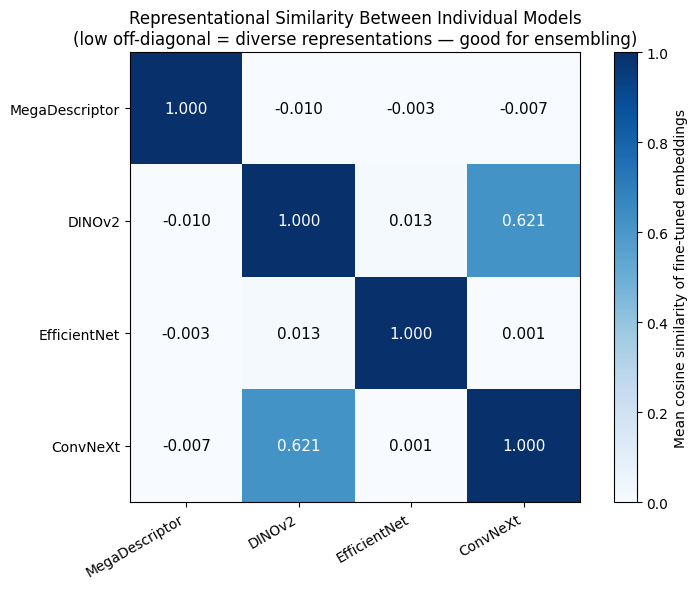

Mean representational similarity (off-diagonal): 0.1025


In [14]:
# 3. Representational similarity between backbone embedding spaces
rep_sim = np.zeros((n_models, n_models))
for i, ni in enumerate(model_names):
    for j, nj in enumerate(model_names):
        if i == j: rep_sim[i,j] = 1.0
        else:
            cos_vals = (norm_embs[ni] * norm_embs[nj]).sum(axis=1)
            rep_sim[i,j] = float(cos_vals.mean())

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(rep_sim, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n_models)); ax.set_xticklabels(short_names, rotation=30, ha='right')
ax.set_yticks(range(n_models)); ax.set_yticklabels(short_names)
for i in range(n_models):
    for j in range(n_models):
        ax.text(j, i, f"{rep_sim[i,j]:.3f}", ha='center', va='center',
                fontsize=11, color='white' if rep_sim[i,j] > 0.6 else 'black')
plt.colorbar(im, ax=ax, label='Mean cosine similarity of fine-tuned embeddings')
ax.set_title('Representational Similarity Between Individual Models\n'
             '(low off-diagonal = diverse representations — good for ensembling)')
plt.tight_layout()
wandb.log({"diversity/representational_similarity": wandb.Image(fig)})
plt.show()

off_diag_rs = rep_sim[~np.eye(n_models, dtype=bool)]
print(f"Mean representational similarity (off-diagonal): {off_diag_rs.mean():.4f}")
wandb.log({"diversity/mean_rep_similarity": float(off_diag_rs.mean())})


## 10. Compute and Latency Tradeoff

In [15]:
# Measure projection-head inference latency
# (Backbone extraction is the same regardless of fusion strategy;
#  what differs is the input dim to the head and the number of backbones needed)
TIMING_BATCHES  = 10
TIMING_BATCH_SZ = 32
latency_ms      = {}

def measure_head_latency(input_dim, name):
    ckpt_path = config["checkpoint_dir"] / f"{name.replace('/', '-').replace(' ', '_')}_best.pth"
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    m    = ArcFaceModel(input_dim=input_dim, num_classes=num_classes,
                        embedding_dim=config["embedding_dim"],
                        hidden_dim=config["hidden_dim"]).to(device)
    m.load_state_dict(ckpt['model_state_dict']); m.eval()
    dummy = torch.randn(TIMING_BATCH_SZ, input_dim).to(device)
    with torch.no_grad():
        for _ in range(3): m.get_embeddings(dummy)  # warmup
    if torch.cuda.is_available(): torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(TIMING_BATCHES): m.get_embeddings(dummy)
    if torch.cuda.is_available(): torch.cuda.synchronize()
    elapsed = (time.perf_counter() - t0) * 1000 / TIMING_BATCHES
    del m
    return elapsed

for cfg in ENSEMBLE_CONFIGS:
    name = cfg["name"]
    dim  = backbone_embs[name]["dim"]
    t    = measure_head_latency(dim, name)
    latency_ms[name] = t
    print(f"  {name:30s}: {t:.2f} ms/batch (head only, {TIMING_BATCH_SZ} samples)")

# Fusion head latency
fusion_latency = measure_head_latency(fused_dim, "FusionEnsemble")
latency_ms["FusionEnsemble"] = fusion_latency
print(f"  {'FusionEnsemble':30s}: {fusion_latency:.2f} ms/batch "
      f"(1 head on {fused_dim}-d input)")

print()
print("Note: total inference cost = backbone extraction time + head time.")
print("      Fusion needs ALL 4 backbones to run; individual needs only 1.")
print(f"      Effective backbone cost for fusion: ~{sum(latency_ms[m['name']] for m in ENSEMBLE_CONFIGS):.1f} ms total extraction")

wandb.log({
    **{f"latency/{n}/ms_per_batch": v for n, v in latency_ms.items()},
    "latency/fusion_head_ms": fusion_latency,
})


  MegaDescriptor-L-384          : 0.32 ms/batch (head only, 32 samples)
  DINOv2-ViT-L-14               : 0.30 ms/batch (head only, 32 samples)
  EfficientNet-B4               : 0.33 ms/batch (head only, 32 samples)
  ConvNeXt-V2-Base              : 0.36 ms/batch (head only, 32 samples)
  FusionEnsemble                : 0.30 ms/batch (1 head on 5376-d input)

Note: total inference cost = backbone extraction time + head time.
      Fusion needs ALL 4 backbones to run; individual needs only 1.
      Effective backbone cost for fusion: ~1.3 ms total extraction



Method                              |    mAP |  Head params |  Latency (ms) | Backbones needed
--------------------------------------------------------------------------------
  FusionEnsemble                    | 0.8358 |    2,893,824 |         0.30 | 4  << BEST
  ConvNeXt-V2-Base                  | 0.8276 |      665,600 |         0.36 | 1
  DINOv2-ViT-L-14                   | 0.8257 |      665,600 |         0.30 | 1
  EfficientNet-B4                   | 0.8245 |    1,058,816 |         0.33 | 1
  MegaDescriptor-L-384              | 0.7748 |      927,744 |         0.32 | 1


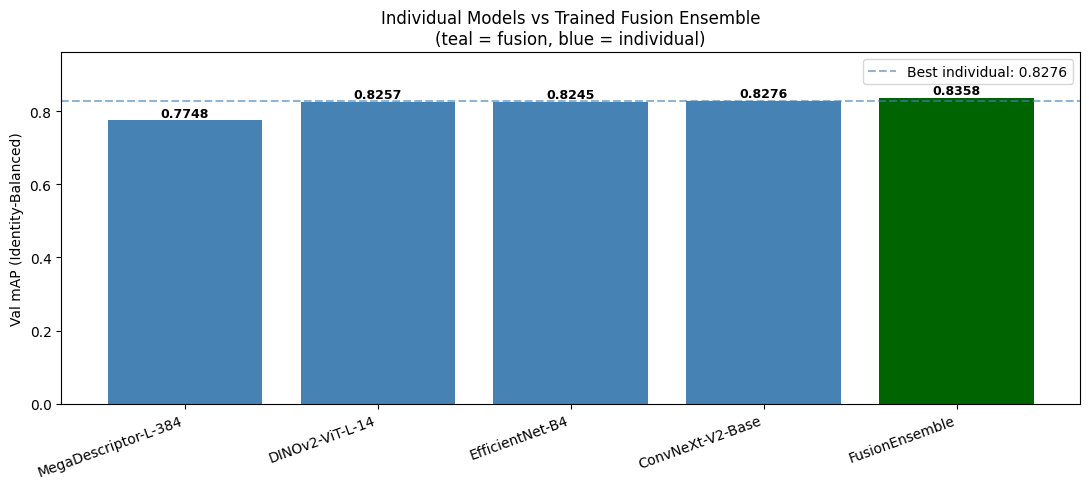

In [16]:
# Tradeoff table
print("\n" + "="*80)
print(f"{'Method':35s} | {'mAP':>6} | {'Head params':>12} | {'Latency (ms)':>13} | Backbones needed")
print("-"*80)

all_method_maps = {n: individual_results[n]['best_map'] for n in model_names}
all_method_maps["FusionEnsemble"] = fusion_map

for name in sorted(all_method_maps, key=lambda n: -all_method_maps[n]):
    m   = all_method_maps[name]
    hp  = individual_head_params.get(name, fusion_head_params)
    lat = latency_ms.get(name, 0)
    bb  = "1" if name != "FusionEnsemble" else str(len(ENSEMBLE_CONFIGS))
    marker = "  << BEST" if name == max(all_method_maps, key=all_method_maps.get) else ""
    print(f"  {name:33s} | {m:.4f} | {hp:>12,} | {lat:>12.2f} | {bb}{marker}")
print("="*80)

# Bar chart
fig, ax = plt.subplots(figsize=(11, 5))
names  = list(all_method_maps.keys())
values = [all_method_maps[n] for n in names]
best_n = max(all_method_maps, key=all_method_maps.get)
colors = ['darkgreen' if n == best_n else
          'mediumseagreen' if n == 'FusionEnsemble' else
          'steelblue' for n in names]
bars = ax.bar(names, values, color=colors)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.axhline(y=best_individual_map, color='steelblue', linestyle='--', alpha=0.6,
           label=f"Best individual: {best_individual_map:.4f}")
ax.set_ylim(0, max(values) * 1.15)
ax.set_ylabel('Val mAP (Identity-Balanced)')
ax.set_title('Individual Models vs Trained Fusion Ensemble\n'
             '(teal = fusion, blue = individual)')
ax.legend()
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
wandb.log({"results/final_comparison_chart": wandb.Image(fig)})
plt.savefig(config['checkpoint_dir'] / 'ensemble_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

wandb.log({
    "results/best_individual_map":  best_individual_map,
    "results/fusion_map":           fusion_map,
    "results/fusion_gain":          fusion_map - best_individual_map,
})


## 11. Generate Competition Submission

Using the best method (individual or fusion) based on val mAP.

In [17]:
test_pairs_df = pd.read_csv(config["data_dir"] / "test.csv")
test_images   = sorted(
    set(test_pairs_df['query_image'].unique()) |
    set(test_pairs_df['gallery_image'].unique()))
test_paths    = [config["data_dir"] / "test/test" / fn for fn in test_images]
print(f"Test pairs: {len(test_pairs_df)}  |  Unique images: {len(test_images)}")

best_method = max(all_method_maps, key=all_method_maps.get)
print(f"Best method: {best_method} (mAP={all_method_maps[best_method]:.4f})")

# Extract test backbone embeddings
test_backbone_embs = {}
for cfg in ENSEMBLE_CONFIGS:
    name      = cfg["name"]
    safe      = name.replace("/", "-").replace(" ", "_")
    transform = get_transforms(cfg["input_size"])
    te_cache  = config["cache_dir"] / f"{safe}_test.npz"

    backbone, emb_dim, _ = load_backbone(cfg, device)
    if te_cache.exists():
        te_emb = np.load(te_cache)["embeddings"]
        print(f"  {name}: loaded test cache {te_emb.shape}")
    else:
        te_emb = extract_embeddings(backbone, test_paths, transform,
                                    config["batch_size"], desc=f"{name} test")
        np.savez_compressed(te_cache, embeddings=te_emb)
    test_backbone_embs[name] = te_emb
    del backbone
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

# Project through the chosen model's head
if best_method == "FusionEnsemble":
    test_input = np.concatenate([test_backbone_embs[m["name"]]
                                  for m in ENSEMBLE_CONFIGS], axis=1)
    input_dim  = fused_dim
    ckpt_name  = "FusionEnsemble"
else:
    test_input = test_backbone_embs[best_method]
    input_dim  = backbone_embs[best_method]["dim"]
    ckpt_name  = best_method

safe_ckpt = ckpt_name.replace("/", "-").replace(" ", "_")
ckpt      = torch.load(config["checkpoint_dir"] / f"{safe_ckpt}_best.pth",
                        map_location=device, weights_only=False)
model     = ArcFaceModel(input_dim=input_dim, num_classes=num_classes,
                          embedding_dim=config["embedding_dim"],
                          hidden_dim=config["hidden_dim"]).to(device)
model.load_state_dict(ckpt['model_state_dict']); model.eval()

with torch.no_grad():
    final_emb = model.get_embeddings(
        torch.FloatTensor(test_input).to(device)).cpu().numpy()
final_emb = final_emb / (np.linalg.norm(final_emb, axis=1, keepdims=True) + 1e-12)

img_to_emb = dict(zip(test_images, final_emb))
print(f"Final test embeddings: {final_emb.shape}")


Test pairs: 137270  |  Unique images: 371
Best method: FusionEnsemble (mAP=0.8358)
Loading MegaDescriptor-L-384...
  embed_dim=1536  params=195,198,516  frozen=True


MegaDescriptor-L-384 test:   0%|          | 0/12 [00:00<?, ?it/s]

Loading DINOv2-ViT-L-14...
  embed_dim=1024  params=304,367,616  frozen=True


DINOv2-ViT-L-14 test:   0%|          | 0/12 [00:00<?, ?it/s]

Loading EfficientNet-B4...
  embed_dim=1792  params=17,548,616  frozen=True


EfficientNet-B4 test:   0%|          | 0/12 [00:00<?, ?it/s]

Loading ConvNeXt-V2-Base...
  embed_dim=1024  params=87,692,800  frozen=True


ConvNeXt-V2-Base test:   0%|          | 0/12 [00:00<?, ?it/s]

Final test embeddings: (371, 256)


In [18]:
similarities = []
for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df),
                   desc="Computing similarities"):
    q = img_to_emb[row['query_image']]
    g = img_to_emb[row['gallery_image']]
    similarities.append(float(np.dot(q, g)))

similarities = np.clip(np.array(similarities), 0.0, 1.0)
print(f"Similarity stats: min={similarities.min():.4f} "
      f"max={similarities.max():.4f} mean={similarities.mean():.4f}")

submission_df   = pd.DataFrame({'row_id': test_pairs_df['row_id'],
                                 'similarity': similarities})
submission_path = config['checkpoint_dir'] / 'submission.csv'
submission_df.to_csv(submission_path, index=False)
submission_df.to_csv('/kaggle/working/submission.csv', index=False)
print(f"Submission saved: {submission_path}")
print(submission_df.head(10))


Computing similarities:   0%|          | 0/137270 [00:00<?, ?it/s]

Similarity stats: min=0.0000 max=0.9941 mean=0.0589
Submission saved: checkpoints/submission.csv
   row_id  similarity
0       0    0.721210
1       1    0.084363
2       2    0.063971
3       3    0.272808
4       4    0.076793
5       5    0.163176
6       6    0.000000
7       7    0.000000
8       8    0.000000
9       9    0.173354


## 12. Save Artifacts

In [19]:
# Best model checkpoint
art = wandb.Artifact("ensemble-best-model", type="model",
                      description=f"Best model: {best_method}")
safe_best = best_method.replace("/", "-").replace(" ", "_")
art.add_file(str(config['checkpoint_dir'] / f'{safe_best}_best.pth'))
wandb.log_artifact(art)

# Submission
sub_art = wandb.Artifact("submission", type="submission",
                          description=f"Submission from {best_method}")
sub_art.add_file(str(submission_path))
wandb.log_artifact(sub_art)

wandb.finish()
print("W&B run completed.")


diversity/identities_hurt,▁
diversity/identities_improved,▁
diversity/mean_error_overlap,▁
diversity/mean_per_id_gain,▁
diversity/mean_rep_similarity,▁
fusion/best_epoch,▁
fusion/best_val_map,▁▁
fusion/epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
fusion/gain_over_best_individual,▁
fusion/head_params,▁
+52,...


W&B run completed.
